In [1]:
#Лабораторная работа №6 Горьков Антон 5130901/30201
# Глава 6. Дискретное косинусное преобразование

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack

from scipy.stats import linregress
from thinkdsp import decorate, UncorrelatedGaussianNoise

In [3]:
# Упражнение 6.1
#
# В этой главе утверждается, что analyze1 требует времени пропорционально n^3,
# а analyze2 - пропорционально n^2.
# Убедитесь в этом, запуская их с несколькими разными массивами и засекая время работы.
#
# Если печатать зависимость времени работы от размера на логарифмической шкале,
# то получится прямая линия с уклоном 3 для analyze1 и с уклоном 2 для analyze2.
#
# Также стоит поупражняться с dct_iv и scipy.fftpack.dct.

In [4]:
signal = UncorrelatedGaussianNoise()
noise = signal.make_wave(duration=1.0, framerate=16384)
noise.ys.shape

(16384,)

In [5]:
loglog = dict(xscale='log', yscale='log')

In [6]:
def plot_bests(ns, bests):    
    plt.plot(ns, bests)
    decorate(**loglog)
    
    x = np.log(ns)
    y = np.log(bests)
    t = linregress(x, y)
    slope = t[0]
    
    return slope

In [7]:
PI2 = np.pi * 2

In [8]:
def analyze1(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.linalg.solve(M, ys)
    return amps

In [9]:
def analyze2(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.dot(M, ys) / 2
    return amps

In [10]:
def dct_iv(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.dot(M, ys) / 2
    return amps

In [11]:
def scipy_dct(ys, fs, ts):
    return scipy.fftpack.dct(ys, type=2, norm='ortho')

In [12]:
def run_speed_test(ns, func):
    results = []
    
    for N in ns:
        print(N)
        ts = (0.5 + np.arange(N)) / N
        freqs = (0.5 + np.arange(N)) / 2
        ys = noise.ys[:N]
        
        result = %timeit -r1 -o func(ys, freqs, ts)
        results.append(result)
        
    bests = [result.best for result in results]
    return bests

In [13]:
ns = 2 ** np.arange(6, 13)
ns

array([  64,  128,  256,  512, 1024, 2048, 4096])

64
52.1 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
128
159 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
256
599 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
512
3.14 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
1024
18.6 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
2048
116 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
4096
766 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


np.float64(2.339586681555192)

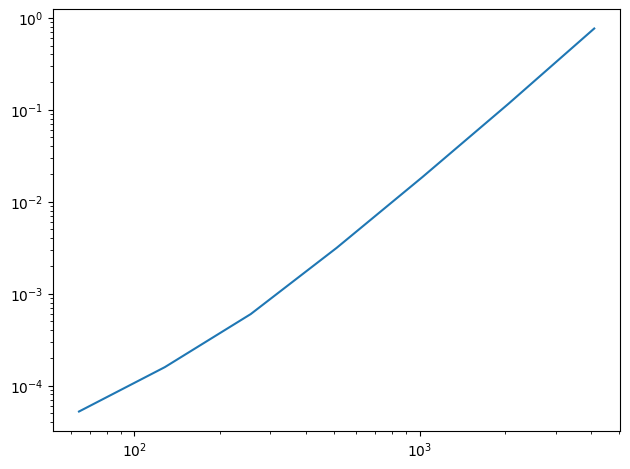

In [14]:
bests1 = run_speed_test(ns, analyze1)
slope1 = plot_bests(ns, bests1)
slope1

64
32.6 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
128
88.7 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
256
311 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
512
1.33 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
1024
6.25 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
2048
45.7 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
4096
91.9 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)


np.float64(2.026118457396364)

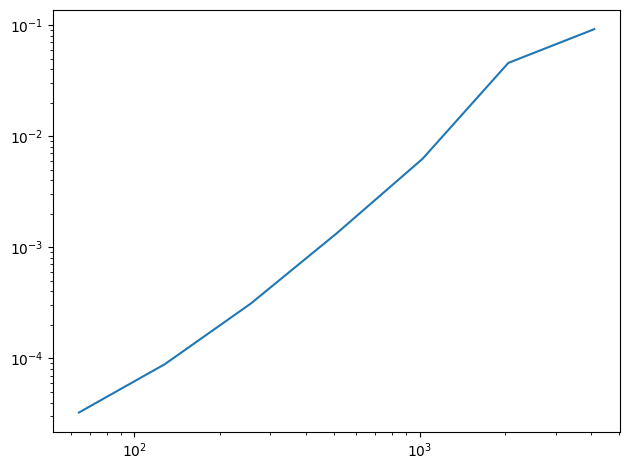

In [15]:
bests2 = run_speed_test(ns, analyze2)
slope2 = plot_bests(ns, bests2)
slope2

64
21.2 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
128
97.5 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
256
291 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
512
1.38 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
1024
5.62 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
2048
23.7 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
4096
104 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)


np.float64(2.0317095650411927)

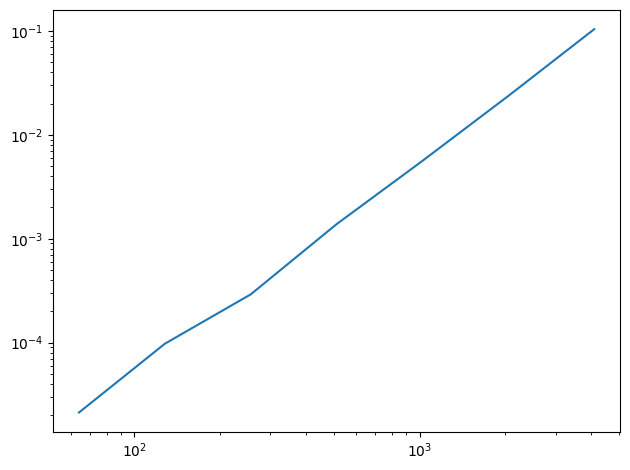

In [16]:
bests3 = run_speed_test(ns, dct_iv)
slope3 = plot_bests(ns, bests3)
slope3

64
2.01 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
128
2.21 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
256
2.46 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
512
3.16 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
1024
4.55 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
2048
7.96 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
4096
14.9 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)


np.float64(0.4727510357732398)

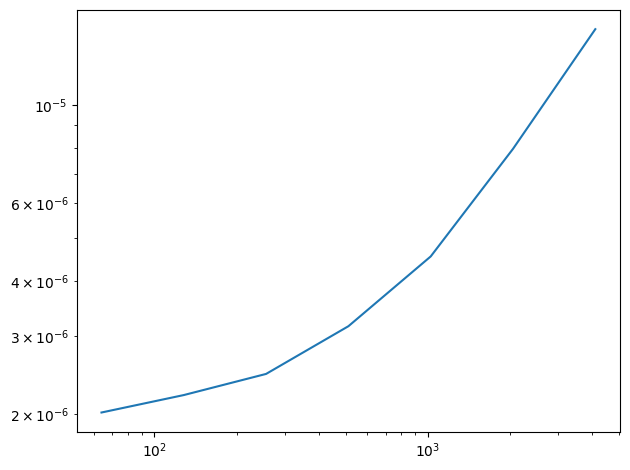

In [17]:
bests4 = run_speed_test(ns, scipy_dct)
slope4 = plot_bests(ns, bests4)
slope4

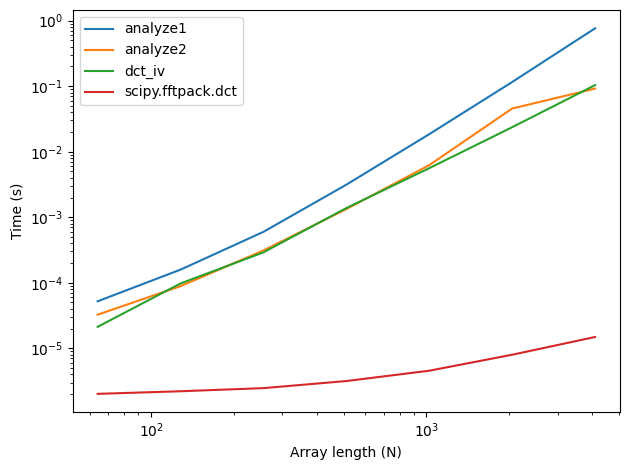

In [18]:
plt.plot(ns, bests1, label='analyze1')
plt.plot(ns, bests2, label='analyze2')
plt.plot(ns, bests3, label='dct_iv')
plt.plot(ns, bests4, label='scipy.fftpack.dct')

decorate(xlabel='Array length (N)',
         ylabel='Time (s)',
         **loglog)

plt.legend()

In [ ]:
# Выводы:
# 1. analyze1 растет заметно быстрее analyze2.
# 2. Для analyze2 наклон на log-log графике обычно близок к 2,
#    что соответствует квадратичной сложности.
# 3. Для analyze1 наклон должен быть ближе к 3, но на практике
#    может отличаться из-за особенностей реализации np.linalg.solve
#    и размеров входных массивов.
# 4. scipy.fftpack.dct работает быстрее обеих функций и обычно
#    показывает рост, близкий к n log n, а не к n^2.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack
import os
from thinkdsp import read_wave, Wave, decorate
from scipy.io import wavfile


In [21]:
# Упражнение 6.2
#
# Одно из основных применений ДКП - это сжатие звука и изображений.
# В простейшей форме ДКП при сжатии работает следующим образом:
#
# 1. Разбивает длинный сигнал на сегменты.
# 2. Вычисляет ДКП каждого сегмента.
# 3. Удаляет компоненты с малой амплитудой.
# 4. При воспроизведении применяет обратное ДКП к каждому сегменту.
#
# Реализуйте версию этого алгоритма и примените его для записи
# музыки или речи.
#
# Сколько компонент можно удалить до того, как разница станет заметной?

In [45]:
framerate, ys = wavfile.read('92002__jcveliz__violin-origional.wav')

if ys.ndim == 2:
    ys = ys.mean(axis=1)

ys = ys.astype(float)
ys /= np.max(np.abs(ys))

wave = Wave(ys, framerate=framerate)
wave.make_audio()

In [46]:
segment = wave.segment(duration=5.0)
segment.make_audio()

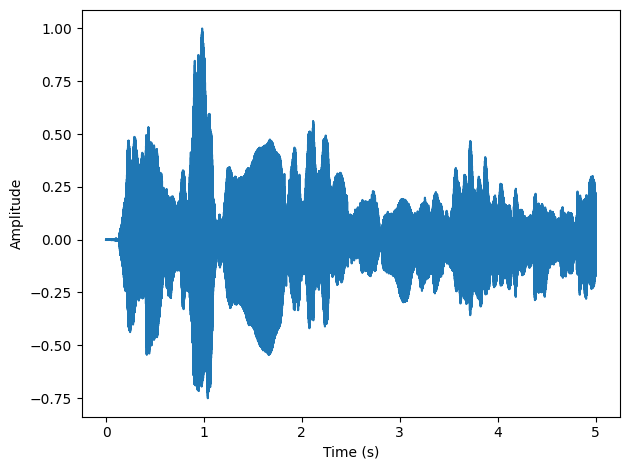

In [47]:
segment.plot()
decorate(xlabel='Time (s)',
         ylabel='Amplitude')

In [48]:
def make_matrix(ys, seg_length):
    n = len(ys)
    m = n // seg_length
    ys = ys[:m * seg_length]
    return ys.reshape(m, seg_length)

In [49]:
def dct_rows(matrix):
    return scipy.fftpack.dct(matrix, type=2, norm='ortho', axis=1)

In [50]:
def idct_rows(matrix):
    return scipy.fftpack.idct(matrix, type=2, norm='ortho', axis=1)

In [51]:
def compress(matrix, thresh):
    result = matrix.copy()
    result[np.abs(result) < thresh] = 0
    return result

In [52]:
def reconstruct_wave(wave, seg_length, thresh):
    matrix = make_matrix(wave.ys, seg_length)
    coeffs = dct_rows(matrix)
    coeffs2 = compress(coeffs, thresh)
    ys = idct_rows(coeffs2).ravel()
    return Wave(ys, framerate=wave.framerate), coeffs, coeffs2

In [65]:
seg_length = 512

In [74]:
wave2, coeffs, coeffs2 = reconstruct_wave(segment, seg_length, thresh=0.1)
wave2.normalize()
wave2.make_audio()

In [83]:
wave2, coeffs, coeffs2 = reconstruct_wave(segment, seg_length, thresh=0.001)

if np.max(np.abs(wave2.ys)) > 0:
    wave2.normalize()
    wave2.make_audio()
else:
    print('Signal is all zeros')

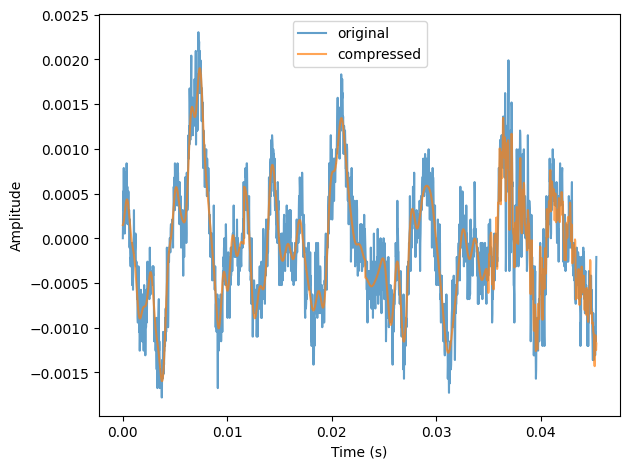

In [84]:
plt.plot(segment.ts[:2000], segment.ys[:2000], label='original', alpha=0.7)
plt.plot(wave2.ts[:2000], wave2.ys[:2000], label='compressed', alpha=0.7)
decorate(xlabel='Time (s)',
         ylabel='Amplitude')
plt.legend()

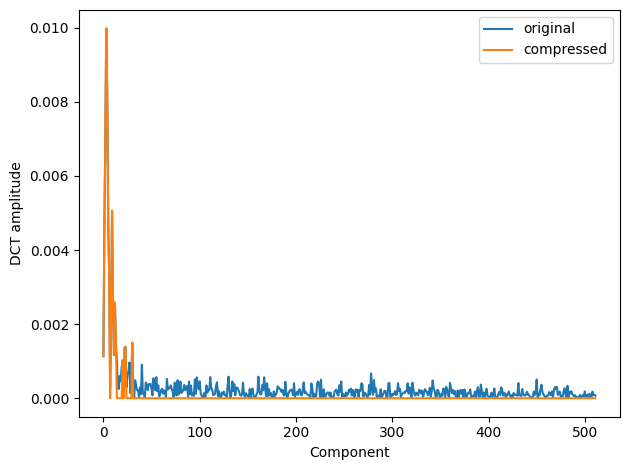

In [86]:
plt.plot(np.abs(coeffs[0]), label='original')
plt.plot(np.abs(coeffs2[0]), label='compressed')
decorate(xlabel='Component',
         ylabel='DCT amplitude')
plt.legend()

In [87]:
total = coeffs.size
nonzero = np.count_nonzero(coeffs2)
removed = total - nonzero

print('total components =', total)
print('nonzero components =', nonzero)
print('removed components =', removed)
print('fraction removed =', removed / total)

total components = 220160
nonzero components = 114976
removed components = 105184
fraction removed = 0.47776162790697674


In [91]:
thresholds = [0.001, 0.005, 0.01, 0.015, 0.02, 0.03, 0.04, 0.05]
fractions = []

for thresh in thresholds:
    wave2, coeffs, coeffs2 = reconstruct_wave(segment, seg_length, thresh)
    total = coeffs.size
    nonzero = np.count_nonzero(coeffs2)
    removed = total - nonzero
    fractions.append(removed / total)
    
    print('thresh =', thresh)
    print('fraction removed =', removed / total)

thresh = 0.001
fraction removed = 0.47776162790697674
thresh = 0.005
fraction removed = 0.673959847383721
thresh = 0.01
fraction removed = 0.7445993822674418
thresh = 0.015
fraction removed = 0.7820812136627907
thresh = 0.02
fraction removed = 0.8073673691860465
thresh = 0.03
fraction removed = 0.8432458212209303
thresh = 0.04
fraction removed = 0.8679187863372093
thresh = 0.05
fraction removed = 0.8868141351744186


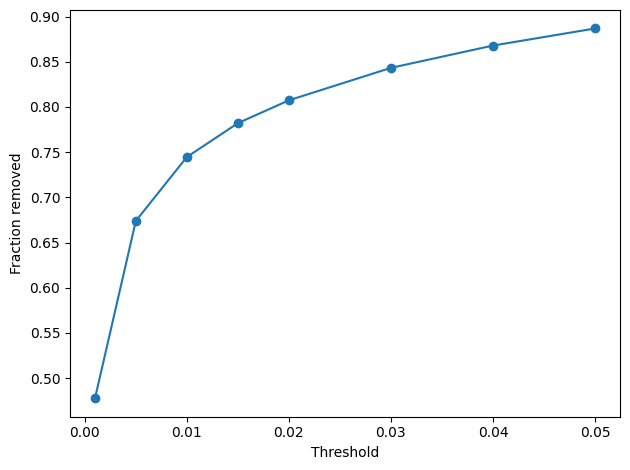

In [92]:
plt.plot(thresholds, fractions, 'o-')
decorate(xlabel='Threshold',
         ylabel='Fraction removed')

In [93]:
# Послушаем несколько вариантов
for thresh in [0.001, 0.01, 0.03, 0.05]:
    wave2, coeffs, coeffs2 = reconstruct_wave(segment, seg_length, thresh)
    wave2.normalize()
    
    print('threshold =', thresh)
    display(wave2.make_audio())

threshold = 0.001


threshold = 0.01


threshold = 0.03


threshold = 0.05


In [94]:
# Можно также использовать долю самых больших коэффициентов
def compress_fraction(matrix, frac):
    result = matrix.copy()
    thresh = np.percentile(np.abs(result), 100 * (1 - frac))
    result[np.abs(result) < thresh] = 0
    return result

In [95]:
def reconstruct_wave_fraction(wave, seg_length, frac):
    matrix = make_matrix(wave.ys, seg_length)
    coeffs = dct_rows(matrix)
    coeffs2 = compress_fraction(coeffs, frac)
    ys = idct_rows(coeffs2).ravel()
    return Wave(ys, framerate=wave.framerate), coeffs, coeffs2

In [96]:
for frac in [0.5, 0.2, 0.1, 0.05]:
    wave2, coeffs, coeffs2 = reconstruct_wave_fraction(segment, seg_length, frac)
    wave2.normalize()
    
    total = coeffs.size
    nonzero = np.count_nonzero(coeffs2)
    
    print('frac =', frac)
    print('fraction kept =', nonzero / total)
    display(wave2.make_audio())

frac = 0.5
fraction kept = 0.5


frac = 0.2
fraction kept = 0.2


frac = 0.1
fraction kept = 0.1


frac = 0.05
fraction kept = 0.05


In [98]:
# Выводы:
# 1. После ДКП значительная часть коэффициентов оказывается малой.
# 2. Если занулить малые коэффициенты, сигнал можно восстановить
#    с удивительно небольшими потерями.
# 3. Чем выше порог, тем больше степень сжатия, но тем сильнее
#    слышимые искажения.
# 4. На практике часто можно удалить большую часть компонент,
#    прежде чем разница станет явно заметной.
# 5. Для практического хранения такого представления удобно использовать
#    разреженные структуры данных.

In [99]:
# Упражнение 6.3
#
# В репозитории этой книги есть блокнот Jupyter под названием
# phase.ipynb, в котором исследуется влияние фазы на восприятие звука.
#
# Прочтите этот блокнот и «погоняйте» примеры.
# Выберите иной сегмент звука и повторите эксперименты.
#
# Можно ли найти некие общие соотношения в фазовой структуре звука
# и его восприятии?

In [100]:
framerate, ys = wavfile.read('92002__jcveliz__violin-origional.wav')

if ys.ndim == 2:
    ys = ys.mean(axis=1)

ys = ys.astype(float)
ys /= np.max(np.abs(ys))

wave = Wave(ys, framerate=framerate)
wave.make_audio()

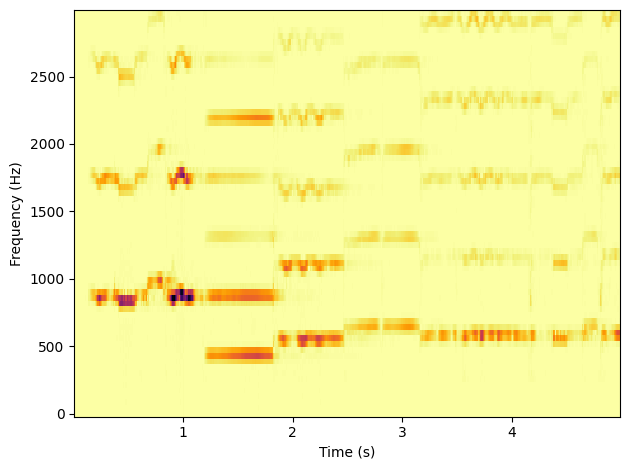

In [101]:
spectrogram = wave.make_spectrogram(seg_length=1024)
spectrogram.plot(high=3000)
decorate(xlabel='Time (s)',
         ylabel='Frequency (Hz)')

In [102]:
# Возьмем другой сегмент, не тот, что в исходном notebook
segment = wave.segment(start=1.2, duration=0.6)
segment.make_audio()

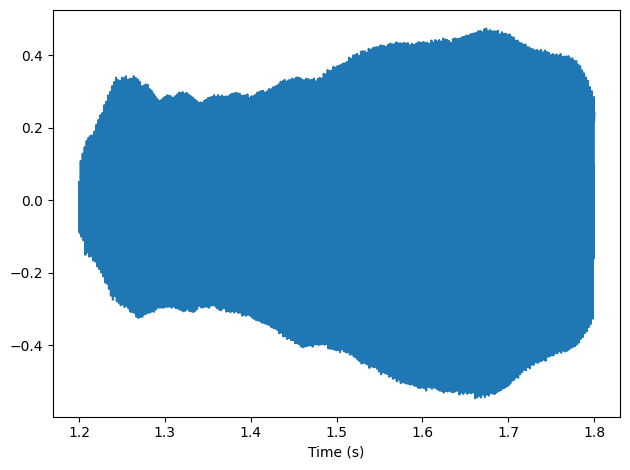

In [103]:
segment.plot()
decorate(xlabel='Time (s)')

In [104]:
spectrum = segment.make_spectrum()

In [105]:
def plot_angle(spectrum, thresh=1):
    angles = spectrum.angles
    angles[spectrum.amps < thresh] = np.nan
    plt.plot(spectrum.fs, angles, 'x')
    decorate(xlabel='Frequency (Hz)',
             ylabel='Phase (radian)')

In [106]:
def plot_three(spectrum, thresh=1):
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 3, 1)
    spectrum.plot()
    decorate(xlabel='Frequency (Hz)',
             ylabel='Amplitude')
    
    plt.subplot(1, 3, 2)
    plot_angle(spectrum, thresh=thresh)
    
    plt.subplot(1, 3, 3)
    wave = spectrum.make_wave()
    wave.unbias()
    wave.normalize()
    wave.segment(duration=0.01).plot()
    decorate(xlabel='Time (s)')
    
    display(wave.make_audio())

In [107]:
def zero_angle(spectrum):
    res = spectrum.copy()
    res.hs = res.amps
    return res
    

In [108]:
def rotate_angle(spectrum, offset):
    res = spectrum.copy()
    res.hs *= np.exp(1j * offset)
    return res

In [109]:
PI2 = np.pi * 2

def random_angle(spectrum):
    res = spectrum.copy()
    angles = np.random.uniform(0, PI2, len(spectrum))
    res.hs *= np.exp(1j * angles)
    return res

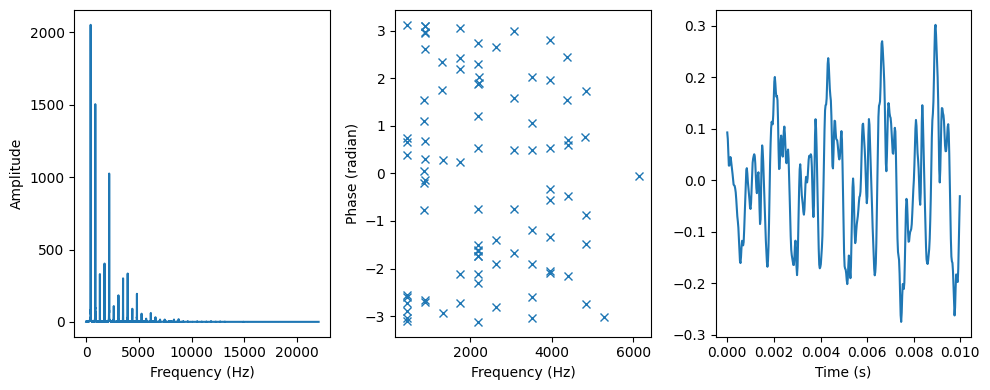

In [110]:
# Исходный сигнал
plot_three(spectrum, thresh=50)

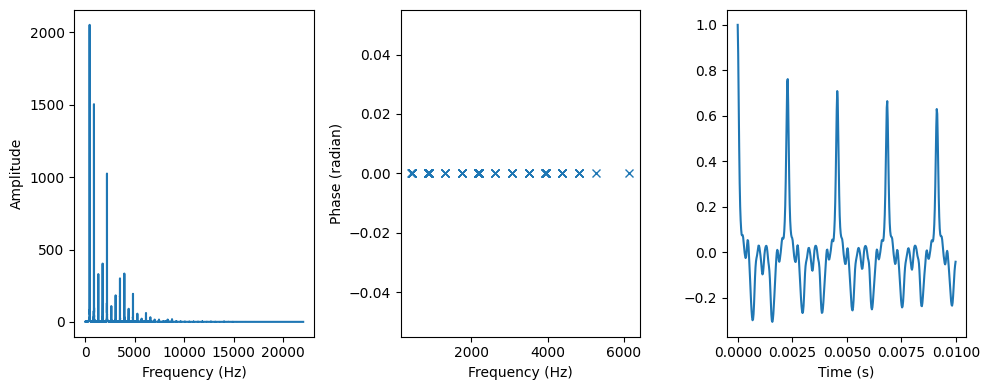

In [111]:
# Все фазы равны нулю
spectrum2 = zero_angle(spectrum)
plot_three(spectrum2, thresh=50)

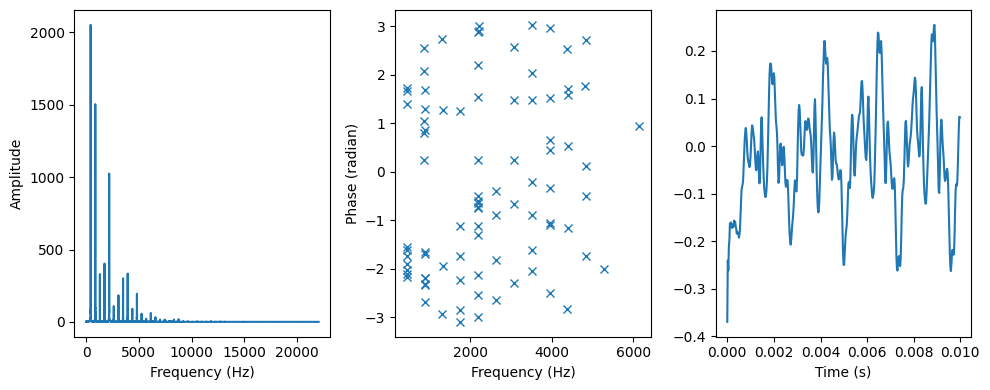

In [112]:
# Все фазы повернуты на одну и ту же величину
spectrum3 = rotate_angle(spectrum, 1)
plot_three(spectrum3, thresh=50)

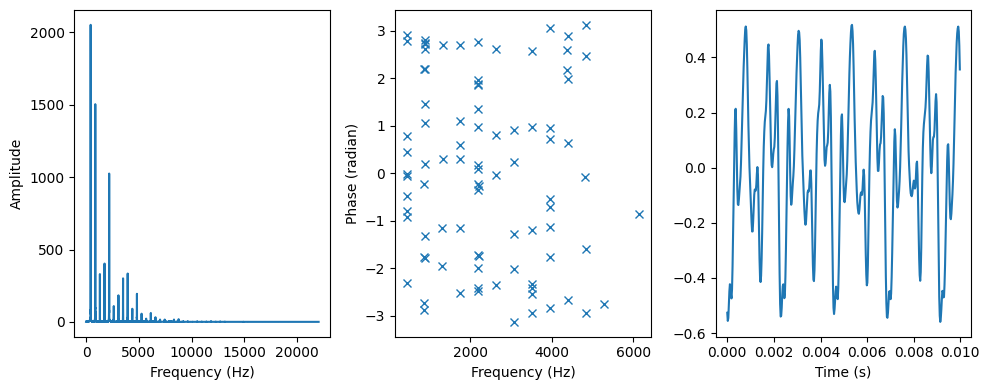

In [113]:
# Фазы случайные
spectrum4 = random_angle(spectrum)
plot_three(spectrum4, thresh=50)

In [114]:
# Сравним формы сигнала на коротком участке
wave1 = spectrum.make_wave()
wave1.unbias()
wave1.normalize()

wave2 = spectrum2.make_wave()
wave2.unbias()
wave2.normalize()

wave3 = spectrum3.make_wave()
wave3.unbias()
wave3.normalize()

wave4 = spectrum4.make_wave()
wave4.unbias()
wave4.normalize()

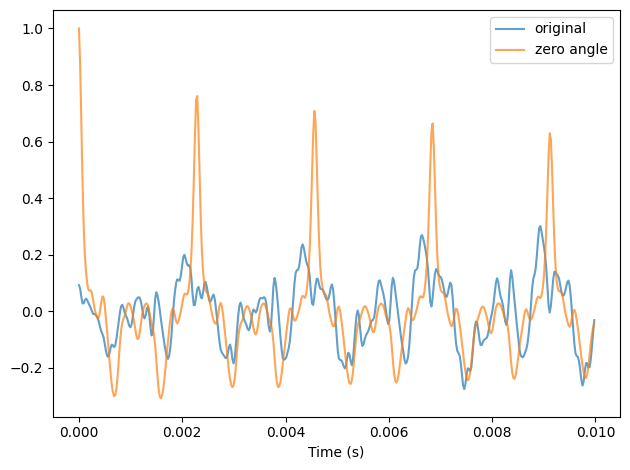

In [115]:
wave1.segment(duration=0.01).plot(label='original', alpha=0.7)
wave2.segment(duration=0.01).plot(label='zero angle', alpha=0.7)
decorate(xlabel='Time (s)')
plt.legend()

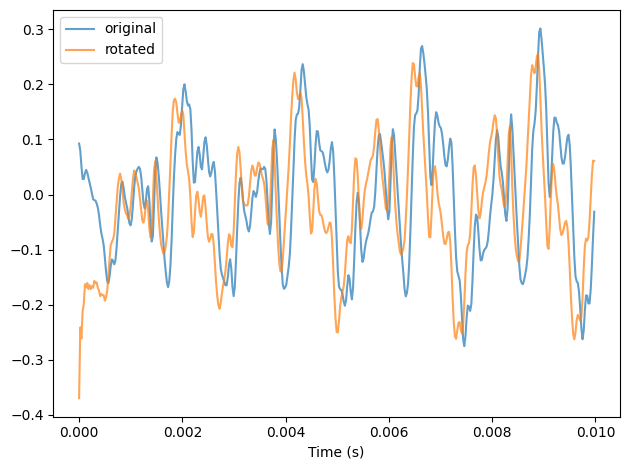

In [116]:
wave1.segment(duration=0.01).plot(label='original', alpha=0.7)
wave3.segment(duration=0.01).plot(label='rotated', alpha=0.7)
decorate(xlabel='Time (s)')
plt.legend()

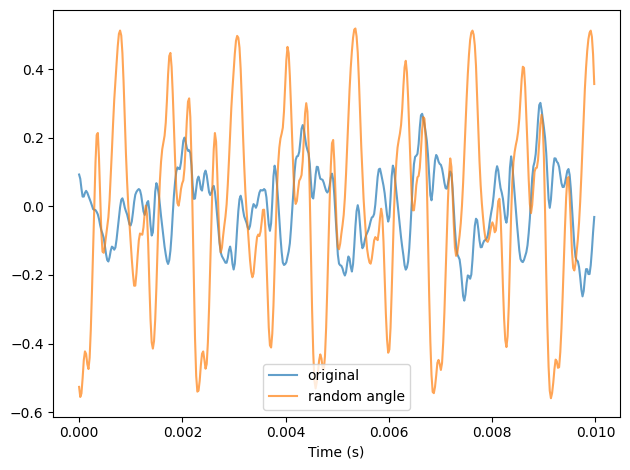

In [117]:
wave1.segment(duration=0.01).plot(label='original', alpha=0.7)
wave4.segment(duration=0.01).plot(label='random angle', alpha=0.7)
decorate(xlabel='Time (s)')
plt.legend()

In [118]:
# Выводы:
# 1. Изменение фазовой структуры сильно меняет форму сигнала во времени.
# 2. Однако поворот всех фаз на одинаковую величину обычно почти не меняет восприятие.
# 3. Обнуление или рандомизация фаз чаще дают слышимые артефакты:
#    "ringing", смазывание атаки, более "breathy" звук.
# 4. Для сложных музыкальных звуков фаза влияет в первую очередь
#    на временную структуру и атаку, а не на грубое ощущение высоты.
# 5. Общее соотношение такое: слух намного чувствительнее к амплитудному спектру,
#    чем к абсолютной фазе, но чувствительность к фазе возрастает,
#    когда она влияет на огибающую и переходные процессы.